In [3]:
import pandas as pd
url="https://raw.githubusercontent.com/DivitMittal/Blinkit-Churn-Analysis/main/dataset/Strategy%20Storm%202025%20-%20Round%202%20dataset%20-%20SSDataset.csv"
    
df_raw = pd.read_csv(url)
print("Dataset shape (rows, columns):", df_raw.shape)

df_raw.head()


Dataset shape (rows, columns): (16093, 12)


,UserID,CustomerAge,Sex,Tenure,ServiceUsageRate,SupportCalls,BillingDelay,PlanType,AgreementDuration,TotalExpenditure,RecentActivity,Churn
0,1,55,Male,20,24,4,6,Standard,Monthly,635,25,0
1,2,28,Male,27,30,4,5,Premium,Quarterly,631,10,0
2,3,65,Female,60,17,7,16,Premium,Quarterly,314,1,1
3,4,53,Male,47,16,8,7,Premium,Annual,527,13,0
4,5,32,Male,56,5,7,15,Premium,Annual,236,25,0


In [4]:
# Statistical summary of numerical columns
df_raw[['ServiceUsageRate', 'Tenure', 'SupportCalls', 'BillingDelay', 'TotalExpenditure']].describe()

,ServiceUsageRate,Tenure,SupportCalls,BillingDelay,TotalExpenditure
count,16093.000000,16093.000000,16093.000000,16093.000000,16093.000000
mean,15.092835,32.110669,5.399615,17.073137,542.270863
std,8.823191,17.090305,3.118676,8.828506,261.841912
min,1.000000,1.000000,0.000000,0.000000,100.000000
25%,7.000000,18.000000,3.000000,10.000000,314.000000
50%,15.000000,33.000000,6.000000,18.000000,534.000000
75%,23.000000,47.000000,8.000000,25.000000,772.000000
max,30.000000,60.000000,10.000000,30.000000,1000.000000


In [7]:
print("---Missing Values Check---")
print(df_raw.isnull().sum())

print("\---Churn Target Distribution---")
print(df_raw['Churn'].value_counts(normalize=True)*100)

---Missing Values Check---
UserID               0
CustomerAge          0
Sex                  0
Tenure               0
ServiceUsageRate     0
SupportCalls         0
BillingDelay         0
PlanType             0
AgreementDuration    0
TotalExpenditure     0
RecentActivity       0
Churn                0
dtype: int64
\---Churn Target Distribution---
0    52.650221
1    47.349779
Name: Churn, dtype: float64


In [8]:
# Compare average metrics between Churned (1) and Retained (0) customers
churn_comparison = df_raw.groupby('Churn')[['CustomerAge', 'Tenure', 'ServiceUsageRate', 'SupportCalls', 'BillingDelay', 'TotalExpenditure', 'RecentActivity']].mean()
churn_comparison.T

Churn,0,1
CustomerAge,41.091703,43.069554
Tenure,28.933790,35.643176
ServiceUsageRate,15.951021,14.138583
SupportCalls,4.488021,6.413255
BillingDelay,12.328101,22.349344
TotalExpenditure,562.761596,519.486352
RecentActivity,15.556474,15.507874


In [9]:
# Churn rate across different contract durations (AgreementDuration)
contract_churn = pd.crosstab(df_raw['AgreementDuration'], df_raw['Churn'], normalize='index') * 100
print("--- Churn Rate by Contract Duration (%) ---")
print(contract_churn)

# Churn rate across different plan types (PlanType)
plan_churn = pd.crosstab(df_raw['PlanType'], df_raw['Churn'], normalize='index') * 100
print("\n--- Churn Rate by Plan Type (%) ---")
print(plan_churn)

--- Churn Rate by Contract Duration (%) ---
Churn                      0          1
AgreementDuration                      
Annual             53.265852  46.734148
Monthly            48.771994  51.228006
Quarterly          55.971116  44.028884

--- Churn Rate by Plan Type (%) ---
Churn             0          1
PlanType                      
Basic     52.108716  47.891284
Premium   53.739356  46.260644
Standard  52.091113  47.908887


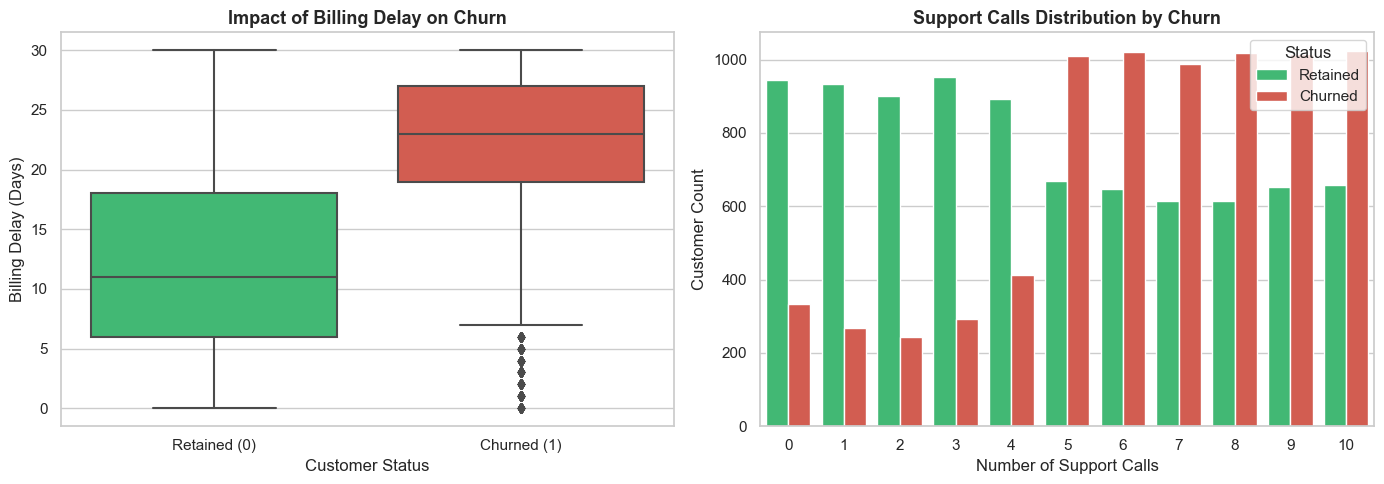

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot: Billing Delay vs Churn
sns.boxplot(
    data=df_raw,
    x='Churn',
    y='BillingDelay',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    ax=axes[0]
)
axes[0].set_title('Impact of Billing Delay on Churn', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0].set_xlabel('Customer Status')
axes[0].set_ylabel('Billing Delay (Days)')

# 2. Countplot: Support Calls vs Churn
sns.countplot(
    data=df_raw,
    x='SupportCalls',
    hue='Churn',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    ax=axes[1]
)
axes[1].set_title('Support Calls Distribution by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Support Calls')
axes[1].set_ylabel('Customer Count')
axes[1].legend(title='Status', labels=['Retained', 'Churned'])

plt.tight_layout()
plt.show()

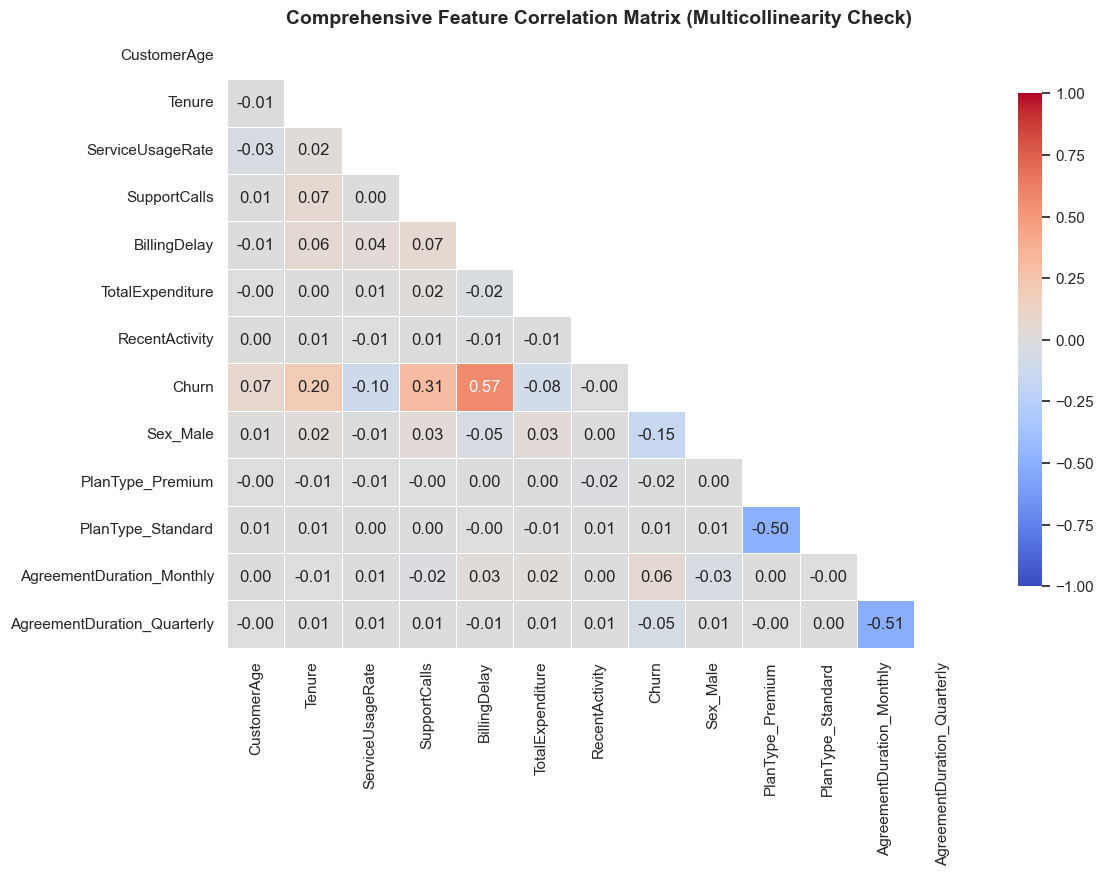

--- Top Correlations with Churn Target ---
Churn                          1.000000
BillingDelay                   0.566770
SupportCalls                   0.308238
Tenure                         0.196022
CustomerAge                    0.071293
AgreementDuration_Monthly      0.055629
PlanType_Standard              0.007909
RecentActivity                -0.002799
PlanType_Premium              -0.015506
AgreementDuration_Quarterly   -0.047272
TotalExpenditure              -0.082523
ServiceUsageRate              -0.102568
Sex_Male                      -0.153941
Name: Churn, dtype: float64


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop UserID and convert categorical columns to numbers (One-Hot Encoding)
df_corr_ready = df_raw.drop(columns=['UserID'])
df_corr_ready = pd.get_dummies(df_corr_ready, drop_first=True)

# 2. Compute correlation matrix
corr_matrix = df_corr_ready.corr()

# 3. Plot full correlation heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Mask upper triangle to avoid duplicate view

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Comprehensive Feature Correlation Matrix (Multicollinearity Check)', fontsize=14, fontweight='bold')
plt.show()

# 4. Show top correlations specifically with Churn target
print("--- Top Correlations with Churn Target ---")
print(corr_matrix['Churn'].sort_values(ascending=False))

In [12]:
# 1. Prepare Feature matrix (X) and Target (Y)
df_model_data = df_raw.drop(columns=['UserID'])
df_model_data = pd.get_dummies(df_model_data, drop_first=True)

X = df_model_data.drop(columns=['Churn'])
Y = df_model_data['Churn']

print("--- Feature Matrix (X) Shape ---")
print("Total Samples (Rows):", X.shape[0])
print("Total Features (Columns):", X.shape[1])
print("\nFeature Columns List:")
print(list(X.columns))

--- Feature Matrix (X) Shape ---
Total Samples (Rows): 16093
Total Features (Columns): 12

Feature Columns List:
['CustomerAge', 'Tenure', 'ServiceUsageRate', 'SupportCalls', 'BillingDelay', 'TotalExpenditure', 'RecentActivity', 'Sex_Male', 'PlanType_Premium', 'PlanType_Standard', 'AgreementDuration_Monthly', 'AgreementDuration_Quarterly']


In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import pandas as pd

# 1. Split data (80% Train, 20% Test)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# 2. Define 3 competitive models
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42)
}

# 3. Train, Evaluate with Cross-Validation and Test Set
results = []

for name, model in models.items():
    # 5-Fold Cross Validation on Train data
    cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='roc_auc')
    
    # Fit model on training set
    model.fit(X_train, Y_train)
    
    # Predict on unseen test set
    Y_pred = model.predict(X_test)
    Y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate key metrics
    test_acc = accuracy_score(Y_test, Y_pred)
    test_auc = roc_auc_score(Y_test, Y_prob)
    test_f1 = f1_score(Y_test, Y_pred)
    
    results.append({
        "Model": name,
        "CV ROC-AUC (Train)": f"{cv_scores.mean() * 100:.2f}%",
        "Test Accuracy": f"{test_acc * 100:.2f}%",
        "Test ROC-AUC": f"{test_auc * 100:.2f}%",
        "Test F1-Score": f"{test_f1 * 100:.2f}%"
    })

df_results = pd.DataFrame(results)
df_results

,Model,CV ROC-AUC (Train),Test Accuracy,Test ROC-AUC,Test F1-Score
0,Logistic Regression,90.95%,82.01%,89.87%,81.40%
1,Random Forest,99.99%,99.38%,99.99%,99.34%
2,Gradient Boosting,99.99%,99.63%,99.99%,99.61%


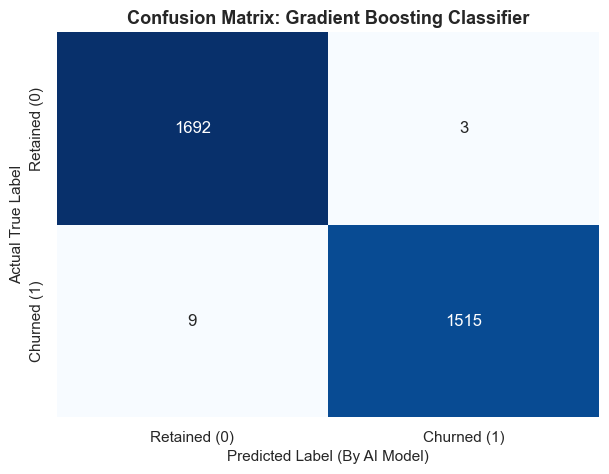

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Retained (0)       0.99      1.00      1.00      1695
 Churned (1)       1.00      0.99      1.00      1524

    accuracy                           1.00      3219
   macro avg       1.00      1.00      1.00      3219
weighted avg       1.00      1.00      1.00      3219



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Select the winning model
best_model = models["Gradient Boosting"]
Y_pred_best = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(Y_test, Y_pred_best)

# Plot confusion matrix heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Retained (0)', 'Churned (1)'],
    yticklabels=['Retained (0)', 'Churned (1)'],
    cbar=False
)

plt.title('Confusion Matrix: Gradient Boosting Classifier', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label (By AI Model)', fontsize=11)
plt.ylabel('Actual True Label', fontsize=11)
plt.show()

# Print detailed precision/recall report
print("--- Detailed Classification Report ---")
print(classification_report(Y_test, Y_pred_best, target_names=['Retained (0)', 'Churned (1)']))

--- Feature Importance Ranking (%) ---
BillingDelay                   45.762872
SupportCalls                   15.534856
Tenure                         11.498946
Sex_Male                        9.304080
ServiceUsageRate                8.215561
CustomerAge                     4.708907
TotalExpenditure                2.646460
AgreementDuration_Monthly       2.069479
AgreementDuration_Quarterly     0.197904
PlanType_Premium                0.033586
PlanType_Standard               0.026548
RecentActivity                  0.000801
dtype: float64


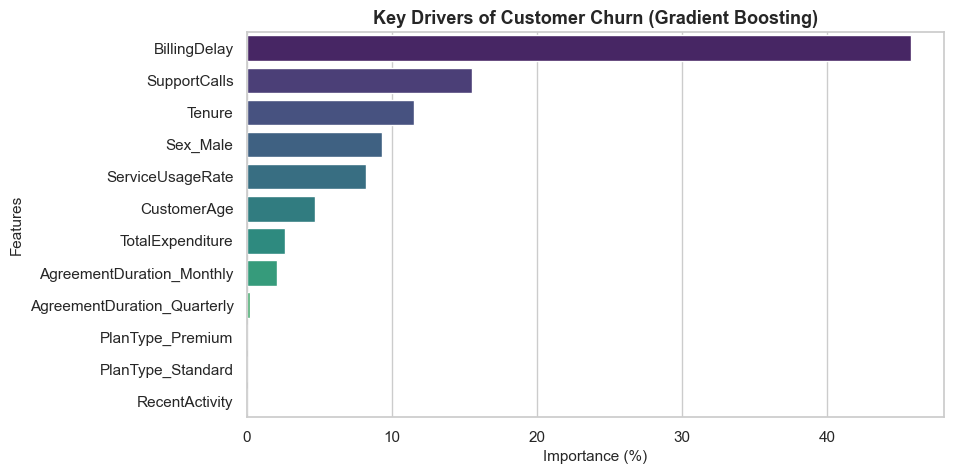

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the best model
feat_importances = pd.Series(
    best_model.feature_importances_ * 100, 
    index=X.columns
).sort_values(ascending=False)

print("--- Feature Importance Ranking (%) ---")
print(feat_importances)

# Plot feature importances
plt.figure(figsize=(9, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')
plt.title('Key Drivers of Customer Churn (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.xlabel('Importance (%)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.show()

In [16]:
import pandas as pd

# Define 3 realistic new customer profiles matching feature columns
new_customers = pd.DataFrame([
    {
        'CustomerAge': 45, 'Tenure': 12, 'ServiceUsageRate': 6, 'SupportCalls': 7, 
        'BillingDelay': 24, 'TotalExpenditure': 400, 'RecentActivity': 15, 'Sex_Male': 0, 
        'PlanType_Premium': 0, 'PlanType_Standard': 1, 'AgreementDuration_Monthly': 1, 'AgreementDuration_Quarterly': 0
    },
    {
        'CustomerAge': 32, 'Tenure': 48, 'ServiceUsageRate': 28, 'SupportCalls': 1, 
        'BillingDelay': 3, 'TotalExpenditure': 850, 'RecentActivity': 5, 'Sex_Male': 1, 
        'PlanType_Premium': 1, 'PlanType_Standard': 0, 'AgreementDuration_Monthly': 0, 'AgreementDuration_Quarterly': 0
    },
    {
        'CustomerAge': 50, 'Tenure': 24, 'ServiceUsageRate': 14, 'SupportCalls': 4, 
        'BillingDelay': 16, 'TotalExpenditure': 550, 'RecentActivity': 12, 'Sex_Male': 1, 
        'PlanType_Premium': 0, 'PlanType_Standard': 0, 'AgreementDuration_Monthly': 1, 'AgreementDuration_Quarterly': 0
    }
], index=['Customer_1 (High Friction)', 'Customer_2 (Loyal Account)', 'Customer_3 (Borderline Case)'])

# Predict churn class and probability
predictions = best_model.predict(new_customers)
probabilities = best_model.predict_proba(new_customers)[:, 1] * 100

# Present results in clean executive table
new_customers['Predicted_Status'] = ['🚨 Churn Risk' if p == 1 else '✅ Retained (Healthy)' for p in predictions]
new_customers['Churn_Probability'] = [f"{prob:.1f}%" for prob in probabilities]

new_customers[['BillingDelay', 'SupportCalls', 'AgreementDuration_Monthly', 'Predicted_Status', 'Churn_Probability']]

,BillingDelay,SupportCalls,AgreementDuration_Monthly,Predicted_Status,Churn_Probability
Customer_1 (High Friction),24,7,1,🚨 Churn Risk,99.5%
Customer_2 (Loyal Account),3,1,0,✅ Retained (Healthy),0.0%
Customer_3 (Borderline Case),16,4,1,✅ Retained (Healthy),0.5%
